## Regression models 
This notebook compares regression models for predicting 'HealthImpactScore', a continuous health outcome variable. We will use air quality and weather variables as predictors and compare model-performance using 10-fold cross-validation. 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import KFold, cross_validate, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")


### Dataset 

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw"/ "air_quality_health_impact_data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


## Define Predictors and Target 
The target variable is 'HealthImpactScore'.

The predictors include air quality and weather measurements. We exclude:
- 'RecordID', because it is only an identifier. 
- 'HealthImpactClass', because it is a separate categorical outcome.
- Health case counts, because they are also health-related outcomes rather than environmemtal predictors 

In [3]:
predictors = [
    'AQI',
    'PM10',
    'PM2_5',
    'NO2',
    'SO2',
    'O3',
    'Temperature',
    'Humidity',
    'WindSpeed',
]

X = df[predictors]
y = df['HealthImpactScore']

print("Predictors:", predictors)
print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictors: ['AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'Temperature', 'Humidity', 'WindSpeed']
Predictor shape: (5811, 9)
Target shape: (5811,)


## Train/Test Split and Cross-Validation 
We reserve 20% of the dataset as a final test set. The remaining 80% is used for training and model selection.

Within the training data, we use shuffled 10-fold cross-validation:
- The training data is divided into 10 folds. 
- Each model is trained on 9 folds and validated on the remaining fold. 
- This repeats until every fold has been used for validation once. 

How to read the metrics:
- 'RMSE' measures prediction error. Lower values are better.
- 'R-squared' measures how much variation in 'HealthImpactScore' is explained by the model. Higher values are better. 

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

cv = KFold(n_splits=10, shuffle=True, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 4648
Testing rows: 1163


In [5]:
def cross_validation_summary(model_name, model):
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring = {
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"  
        }
    )

    return {
        "Model": model_name,
        "Mean CV RMSE": -scores["test_rmse"].mean(),
        "Mean CV R-squared": scores["test_r2"].mean()
    }

def test_summary(model_name, model):
    model.fit(X_train, y_train)
    preditction = model.predict(X_test)

    return {
        "Model": model_name,
        "Test RMSE": np.sqrt(mean_squared_error(y_test, preditction,)),
        "Test R-squared": r2_score(y_test, preditction)
    }

## Multiple Linear Regression Baseline 
Multiple Linear Regression estimates a linear relationship between the environmental predictors and 'HealthImpactScore'. This gives us a baseline for comparing other models.

In [6]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("LinearRegression", LinearRegression())
])

linear_cv = cross_validation_summary("Multiple Linear Regression", linear_model)
pd.DataFrame([linear_cv])

,Model,Mean CV RMSE,Mean CV R-squared
0,Multiple Linear Regression,9.462888,0.482713


How to read the output:
- 'Mean CV RMSE' is the average prediction error across the validation folds. 
- 'Mean CV R-squared' measures the average proportion of variation explained by the model. 
- This baseline will be compared with more flexible models below.


## Lasso Regression
Lasso Regression adds regularization to a linear regression model. This can reduce the influence of weaker predictors and may set some coefficients close to zero. 

We compare several 'alpha' values:
- Smaller values apply weaker regularization. 
- Larger values apply stronger regularization.
- The best value is the one with the lowest cross-validation RMSE.

In [7]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=100000))
])

lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid={
        "lasso__alpha": np.logspace(-4, 2, 13)
    },
    scoring="neg_root_mean_squared_error",
    cv=cv
)

lasso_search.fit(X_train, y_train)

print("Best alpha:", lasso_search.best_params_["lasso__alpha"])
print("Best CV RMSE:", -lasso_search.best_score_)

Best alpha: 0.03162277660168379
Best CV RMSE: 9.46248507521383


In [8]:
lasso_results = pd.DataFrame({
    "Alpha": lasso_search.cv_results_["param_lasso__alpha"].astype(float),
    "Mean CV RMSE": -lasso_search.cv_results_["mean_test_score"]
}).sort_values("Alpha")

lasso_results

,Alpha,Mean CV RMSE
0,0.000100,9.462887
1,0.000316,9.462884
2,0.001000,9.462874
3,0.003162,9.462847
4,0.010000,9.462749
5,0.031623,9.462485
6,0.100000,9.463535
7,0.316228,9.483445
8,1.000000,9.709037
9,3.162278,10.900611


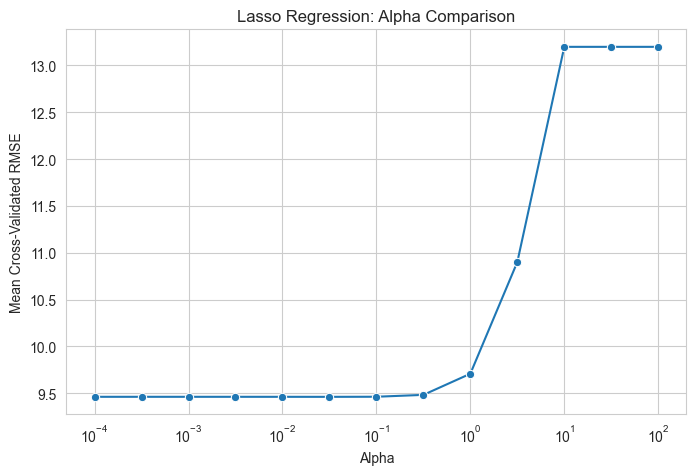

In [9]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=lasso_results, x="Alpha", y="Mean CV RMSE", marker="o")
plt.xscale("log")
plt.title("Lasso Regression: Alpha Comparison")
plt.xlabel("Alpha")
plt.ylabel("Mean Cross-Validated RMSE")
plt.show()

How to read the plot:
- Each point represents one regularization strength.
- Lower RMSE values indicate better performance.
- The selected alpha value has the lowest cross-validation RMSE. 

## Polynomial Regression 
Polynomial Regression test whether nonlinear relationships improve predictions.

We compare:
- Degree '1': linear model 
- Degree '2': adds squared terms and interactions 
- Degree '3': adds more nonlinear terms 
- Degree '5': creates a more flexible model 

Higher degress may fit complex patterns, but they may also overfit. Cross-validation helps identify the best degree.

In [10]:
polynomial_pipeline = Pipeline([
    ("polynomial_features", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("LinearRegression", LinearRegression())
])

polynomial_search = GridSearchCV(
    estimator=polynomial_pipeline,
    param_grid={
        "polynomial_features__degree": [1, 2, 3, 5]
    },
    scoring="neg_root_mean_squared_error",
    cv=cv
)

polynomial_search.fit(X_train, y_train)

print("Best polynomial degree:", polynomial_search.best_params_["polynomial_features__degree"])
print("Best CV RMSE:", -polynomial_search.best_score_)

Best polynomial degree: 3
Best CV RMSE: 2.2239145429842724


In [11]:
polynomial_results = pd.DataFrame({
    "Degree": polynomial_search.cv_results_["param_polynomial_features__degree"].astype(int),
    "Mean CV RMSE": -polynomial_search.cv_results_["mean_test_score"]
}).sort_values("Degree")

polynomial_results

,Degree,Mean CV RMSE
0,1,9.462888
1,2,4.722881
2,3,2.223915
3,5,2.460919


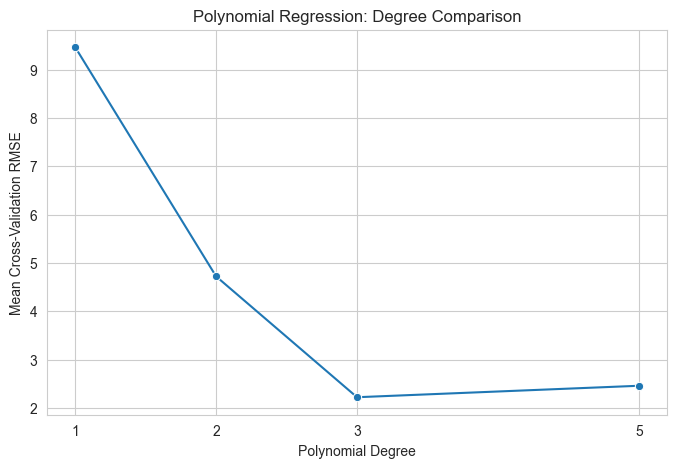

In [12]:
plt.figure(figsize=(8, 5))
sns.lineplot(data = polynomial_results, x="Degree", y="Mean CV RMSE", marker="o")
plt.title("Polynomial Regression: Degree Comparison")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Cross-Validation RMSE")
plt.xticks([1, 2, 3, 5])
plt.show()

## Polynomial Feature Complexity 
Polynomial Regression improves performance by creating new featrues from the original predictors. For example, instead of only using 'AQI', 'PM2_5', and 'NO2', the model can also use terms such as 'AQ^2', 'AQI PM2_5' or 'AQI^3'. This makes the model more flexible, but it also increases complexity. Since we used '9' original environmental predictors and selected polynomial degress '3', we need to check how many polynomial terms were created. 

In [13]:
poly_counter = PolynomialFeatures(degree = 3, include_bias=False)

poly_counter.fit(X_train)

poly_feature_names = poly_counter.get_feature_names_out(predictors)

print("Original number of predictors:", len(predictors))
print("Polynomial degree:", 3)
print("Number of polynomial features created:", len(poly_feature_names))


Original number of predictors: 9
Polynomial degree: 3
Number of polynomial features created: 219


## Polynomial Regression with Lasso Regularization 
Because degree '3' Polynomial Regression creates many polynomial terms, we also apply Lasso regularization after creating the polynomial featrues. 
Lasso helps control model complexity by shrinking weaker coefficients toward zero. Coefficients that become exactly zero can be interpreted as terms the model did not need. This gives us a more specific way to identify which polynomial features were most important. 

To keep the regularized polynomial model efficient, we used 5-fold cross-validation and a smaller alpha grid. This is all just meant to control model complexity and identify important polynomial terms, while the main model comparison still uses the broader cross-validation setup.

In [14]:
poly_lasso_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=100000, tol = 0.01, random_state=42))
])

poly_lasso_search = GridSearchCV(
    estimator=poly_lasso_pipeline,
    param_grid={
        "lasso__alpha": [0.001, 0.01, 0.1, 1, 10]
    },
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

poly_lasso_search.fit(X_train, y_train)
print("Best alpha for polynomial lasso:", poly_lasso_search.best_params_["lasso__alpha"])
print("Best CV RMSE for polynomial lasso:", -poly_lasso_search.best_score_)


Best alpha for polynomial lasso: 0.001
Best CV RMSE for polynomial lasso: 2.2334089617430175


The best alpha was '0.001', which means the model performed best with light regularization. The cross-validation RMSE was approximately '2.233', which is still close to the original degree '3' Polynomial Regregression result. This suggests that Polynomial Regression remainds strong, while Lasso regularization helps control complexity and identify which polynomial terms are most useful. 

In [15]:
best_poly_lasso_model = poly_lasso_search.best_estimator_

poly_lasso_prediction = best_poly_lasso_model.predict(X_test)

poly_lasso_test_rmse = np.sqrt(mean_squared_error(y_test, poly_lasso_prediction))
poly_lasso_test_r2 = r2_score(y_test, poly_lasso_prediction)

print("Polynomial Lasso Test RMSE:", poly_lasso_test_rmse)
print("Polynomial Lasso Test R-squared:", poly_lasso_test_r2)

Polynomial Lasso Test RMSE: 2.302665188658586
Polynomial Lasso Test R-squared: 0.9717010175232744


In [26]:
best_poly_lasso_model = poly_lasso_search.best_estimator_

poly_lasso_feature_names = best_poly_lasso_model.named_steps["poly"].get_feature_names_out(predictors)
poly_lasso_coefficients = best_poly_lasso_model.named_steps["lasso"].coef_

poly_lasso_coefficients_df = pd.DataFrame({
    "Feature": poly_lasso_feature_names,
    "Coefficient": poly_lasso_coefficients
})

nonzero_poly_lasso_coef_df = poly_lasso_coefficients_df[
    poly_lasso_coefficients_df["Coefficient"] != 0
].copy()

nonzero_poly_lasso_coef_df["Absolute Coefficient"] = nonzero_poly_lasso_coef_df["Coefficient"].abs()

nonzero_poly_lasso_coef_df = nonzero_poly_lasso_coef_df.sort_values(
    "Absolute Coefficient", 
    ascending=False
)

print("Total polynomial features:", len(poly_lasso_feature_names))
print("Number of nonzero coefficients after Lasso:", len(nonzero_poly_lasso_coef_df))

nonzero_poly_lasso_coef_df.head(15)

Total polynomial features: 219
Number of nonzero coefficients after Lasso: 194


,Feature,Coefficient,Absolute Coefficient
9,AQI^2,-119.224789,119.224789
0,AQI,116.797291,116.797291
11,AQI PM2_5,-37.523593,37.523593
54,AQI^3,36.305802,36.305802
10,AQI PM10,-26.797914,26.797914
14,AQI O3,-26.763331,26.763331
2,PM2_5,25.228448,25.228448
12,AQI NO2,-18.423881,18.423881
5,O3,18.232533,18.232533
56,AQI^2 PM2_5,17.387151,17.387151


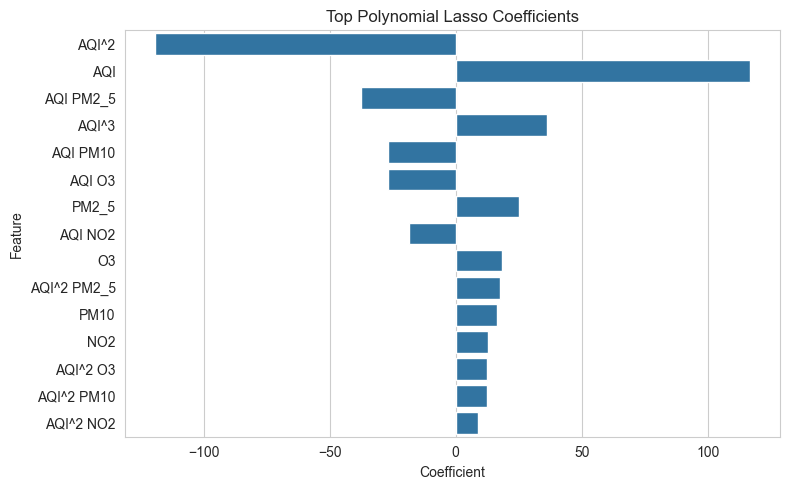

In [17]:
top_poly_lasso_features = nonzero_poly_lasso_coef_df.head(15)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_poly_lasso_features, 
    x="Coefficient", 
    y="Feature", 
)

plt.title("Top Polynomial Lasso Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


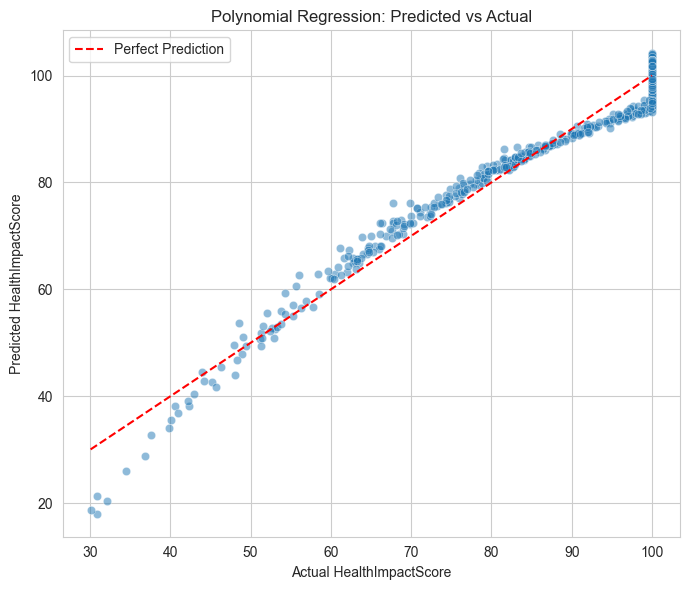

In [27]:
best_poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("LinearRegression", LinearRegression())
])

best_poly_model.fit(X_train, y_train)

best_poly_predictions = best_poly_model.predict(X_test)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_poly_predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()], 
    [y_test.min(), y_test.max()], 
    color="red", 
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Polynomial Regression: Predicted vs Actual")
plt.xlabel("Actual HealthImpactScore")
plt.ylabel("Predicted HealthImpactScore")
plt.legend()
plt.tight_layout()
plt.show()

## Polynomial Model Interpretation 
Degree '3' Polynomial Regression performed best for predicting 'HealthImpactScore', but it created many terms from the original predictors. With '9' environmental predictors , degree '3' Polynomial Features created '219' features, including squared, cubed, and interaction terms. To control model complexity, we aplied Lasso regularization to the polynomial featrues. Lasso shrinks weaker coefficients toward zero, allowing us to identify which polynomial terms were most sueful. This akes the polynomial model more interpretable and less broad. The actual vs predicted plot shows that the Polynomial Regression model predicted 'HealthImpactScore' closely, whith most points near the diagonal line. This supports the numerical results showing that Polynomial Regression had the lowest RMSE and highest R-squared among the regression models.

## Reduced Polynomial Regression using only Important Predictors 
The full degree '3' polynomial model used all 9 original predictors and created 219 polynomial features. Even after applying Lasso regularization, most coefficients remained nonzero, so the model was still farily complex. To make the regression analysis more specific and easier to interpret, we fit a reduced polynomial regression model using only the most important original predictors identified from the polynomial lasso results: 'AQI', 'PM2_5', 'PM10', 'NO2', and 'O3'. These variables were selected because the largest polynomial lasso coefficients were mostly AQI-related or pollutant-related terms.

In [29]:
important_predictors = ['AQI', 'PM10', 'PM2_5', 'NO2', 'O3']

x_train_important = X_train[important_predictors]
x_test_important = X_test[important_predictors]

reduced_poly_counter = PolynomialFeatures(degree=3, include_bias=False)
reduced_poly_counter.fit(x_train_important)

reduced_poly_feature_names = reduced_poly_counter.get_feature_names_out(important_predictors)

print("Original number of predictors used in the full model:", len(predictors))
print("Full degree 3 polynomial features:", len(poly_feature_names))
print("Reduced predictors:", important_predictors)
print("Number of predictors used in the reduced model:", len(important_predictors))
print("reduced_degree 3 polynomial features:", len(reduced_poly_feature_names))

Original number of predictors used in the full model: 9
Full degree 3 polynomial features: 219
Reduced predictors: ['AQI', 'PM10', 'PM2_5', 'NO2', 'O3']
Number of predictors used in the reduced model: 5
reduced_degree 3 polynomial features: 55


This reduced model lowers the number of polynomial featrues from 219 to 55. This makes the model easier to explain while still allowing nonlinear relationships between air pollution variables and 'HealthImpactScore'.

In [30]:
reduced_poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("LinearRegression", LinearRegression())
])

reduced_poly_cv = cross_validate(
    reduced_poly_model,
    x_train_important,
    y_train,
    cv=cv,
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"  
    }
)

reduced_poly_model.fit(x_train_important, y_train)
reduced_poly_predictions = reduced_poly_model.predict(x_test_important)

reduced_poly_test_rmse = np.sqrt(mean_squared_error(y_test, reduced_poly_predictions))
reduced_poly_test_r2 = r2_score(y_test, reduced_poly_predictions)

print("Reduced Polynomial Regression CV RMSE:", -reduced_poly_cv["test_rmse"].mean())
print("Reduced Polynomial Regression CV R-squared:", reduced_poly_cv["test_r2"].mean())
print("Reduced Polynomial Regression Test RMSE:", reduced_poly_test_rmse)
print("Reduced Polynomial Regression Test R-squared:", reduced_poly_test_r2)

Reduced Polynomial Regression CV RMSE: 2.3374444085845143
Reduced Polynomial Regression CV R-squared: 0.9685117777308848
Reduced Polynomial Regression Test RMSE: 2.3934670505287063
Reduced Polynomial Regression Test R-squared: 0.9694251640314125


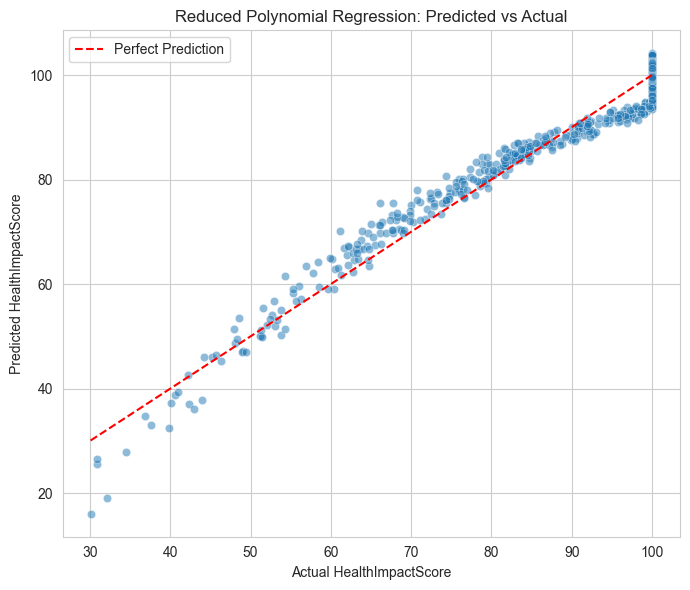

In [31]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=y_test, 
    y=reduced_poly_predictions, 
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()], 
    [y_test.min(), y_test.max()], 
    color="red", 
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Reduced Polynomial Regression: Predicted vs Actual")
plt.xlabel("Actual HealthImpactScore")  
plt.ylabel("Predicted HealthImpactScore")
plt.legend()
plt.tight_layout()
plt.show()

The Scatter plot compares the actual 'HealthImpactScore' values to the scores predicted by the reduced polynomial model. Points closer to the red dashes line represent better predictions. If the reduced model performs similarly to the full polynommial model, it suggests that the smaller set of pollutant variables captures most of the useful predictive information.

In [32]:
reduced_poly_summary = pd.DataFrame({
    "Model": ["Reduced Polynomial Regression"],
    "Number of Original Predictors": [len(important_predictors)],
    "Number of Polynomial Features": [len(reduced_poly_feature_names)],
    "Test RMSE": [reduced_poly_test_rmse],
    "Test R-squared": [reduced_poly_test_r2]
})
reduced_poly_summary

,Model,Number of Original Predictors,Number of Polynomial Features,Test RMSE,Test R-squared
0,Reduced Polynomial Regression,5,55,2.393467,0.969425


## Principal Component Regression 
Principal Component Regression (PCR) uses PCA to summarize variables into a small number of components. A linear regression model is then fitted using those components. 

Our proposal suggested comparing up to 10 components. However, we use 9 environmental predictors, so the maximum possible number of components is 9.

We compare '1', '2', '3', '5', and '9' principal components. 

In [18]:
pcr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("LinearRegression", LinearRegression())
])

pcr_search = GridSearchCV(
    estimator=pcr_pipeline,
    param_grid={
        "pca__n_components": [1, 2, 3, 5, 9]
    },
    scoring="neg_root_mean_squared_error",
    cv=cv
)

pcr_search.fit(X_train, y_train)

print("Best number of components:", pcr_search.best_params_["pca__n_components"])
print("Best CV RMSE:", -pcr_search.best_score_) 

Best number of components: 9
Best CV RMSE: 9.462887979018387


In [19]:
pcr_results = pd.DataFrame({
    "Number of Components": pcr_search.cv_results_["param_pca__n_components"].astype(int),
    "Mean CV RMSE": -pcr_search.cv_results_["mean_test_score"]
}).sort_values("Number of Components")

pcr_results

,Number of Components,Mean CV RMSE
0,1,12.506739
1,2,12.182722
2,3,11.941964
3,5,10.428318
4,9,9.462888


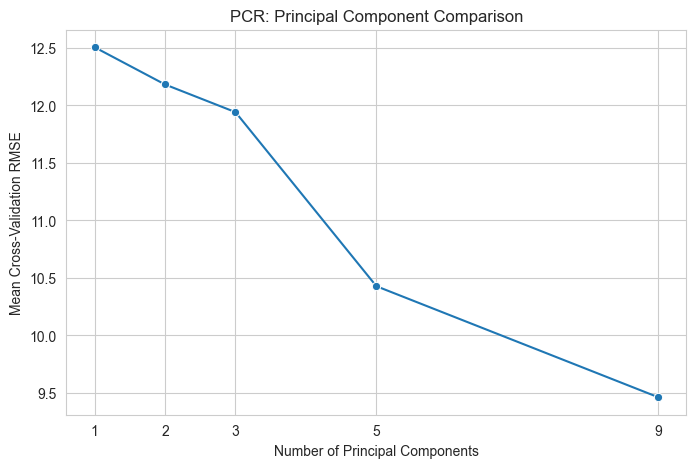

In [20]:
plt.figure(figsize=(8, 5))
sns.lineplot(data = pcr_results, x="Number of Components", y="Mean CV RMSE", marker="o")
plt.title("PCR: Principal Component Comparison")
plt.xlabel("Number of Principal Components")
plt.ylabel("Mean Cross-Validation RMSE")
plt.xticks([1, 2, 3, 5, 9])
plt.show()

## Final Model Comparison 
This section compares final performance on the held-out test set.

How to read the output:
- Lower test RMSE values indicate better predictions. 
- Higher test R-squared values indicate that a model explains more variation in 'HealthImpactScore'. 
- The test set was not used when selecting hyperparameters, so it provides a final model comparison.


In [36]:
def test_model_summary(model_name, model, X_train_data, X_test_data):
    model.fit(X_train_data, y_train)
    predictions = model.predict(X_test_data)

    return {
        "Model": model_name,
        "Test RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "Test R-squared": r2_score(y_test, predictions)
    }


comparison_results = pd.DataFrame([
    test_model_summary("Multiple Linear Regression", linear_model, X_train, X_test),
    test_model_summary("Lasso Regression", lasso_search.best_estimator_, X_train, X_test),
    test_model_summary("Principal Component Regression", pcr_search.best_estimator_, X_train, X_test),
    test_model_summary("Polynomial Regression", polynomial_search.best_estimator_, X_train, X_test),
    {
        "Model": "Polynomial Lasso Regression",
        "Test RMSE": poly_lasso_test_rmse,
        "Test R-squared": poly_lasso_test_r2
    },
    {
        "Model": "Reduced Polynomial Regression",
        "Test RMSE": reduced_poly_test_rmse,
        "Test R-squared": reduced_poly_test_r2
    }
])

comparison_results = comparison_results.sort_values("Test RMSE")

comparison_results

,Model,Test RMSE,Test R-squared
4,Polynomial Lasso Regression,2.302665,0.971701
3,Polynomial Regression,2.303857,0.971672
5,Reduced Polynomial Regression,2.393467,0.969425
0,Multiple Linear Regression,9.634493,0.504587
2,Principal Component Regression,9.634493,0.504587
1,Lasso Regression,9.637538,0.504274


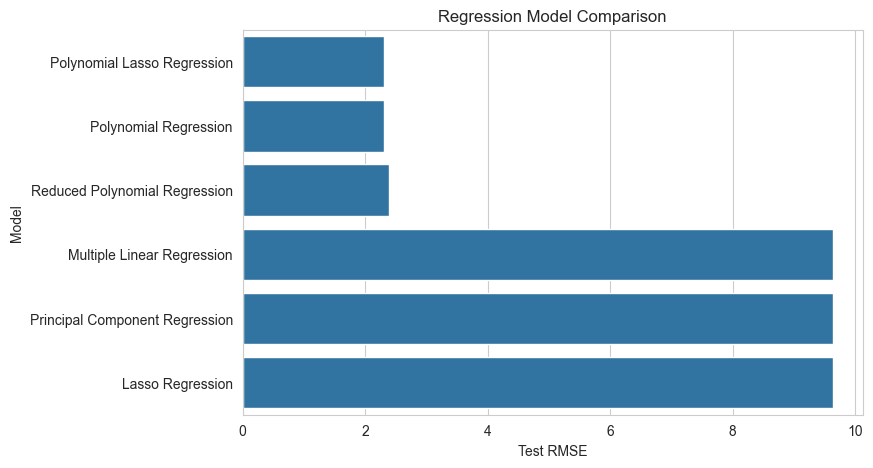

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_results, x="Test RMSE", y="Model")
plt.title("Regression Model Comparison")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.show()

In [38]:
# Refit best polynomial model on the FULL dataset

final_regression_model = polynomial_search.best_estimator_
final_regression_model.fit(X, y)
print("Best Degree:", final_regression_model.named_steps["polynomial_features"].degree)

Best Degree: 3


In [39]:
poly = final_regression_model.named_steps["polynomial_features"]
model = final_regression_model.named_steps["LinearRegression"]

feature_names = poly.get_feature_names_out(predictors)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
9,AQI^2,-124.221752,124.221752
0,AQI,121.825471,121.825471
11,AQI PM2_5,-39.946443,39.946443
54,AQI^3,37.867816,37.867816
10,AQI PM10,-28.908742,28.908742
14,AQI O3,-27.857580,27.857580
2,PM2_5,25.830874,25.830874
12,AQI NO2,-20.806662,20.806662
1,PM10,18.226341,18.226341
56,AQI^2 PM2_5,17.863035,17.863035


## Conclusion

The full degree `3` Polynomial Regression model performed best for predicting `HealthImpactScore`. It produced a test RMSE of approximately `2.304` and a test R-squared value of approximately `0.972`, meaning it explained about 97.2% of the variation in the held-out test set. The predicted vs actual scatter plot also showed that most predictions were close to the red dashed line, so the model's predicted scores were generally close to the actual scores.

However, the full polynomial model was complex because it used all `9` original predictors and expanded them into `219` polynomial features. We applied Polynomial Lasso Regression to control complexity and identify important terms. Lasso kept `194` nonzero coefficients, so it removed some weaker terms, but the model still remained fairly complex.

To make the analysis more specific and easier to interpret, we also fit a reduced degree `3` Polynomial Regression model using only `5` important pollutant predictors: `AQI`, `PM10`, `PM2_5`, `NO2`, and `O3`. This reduced the feature count from `219` to `55` polynomial features. The reduced model had a test RMSE of approximately `2.393` and a test R-squared value of approximately `0.969`, which was only slightly worse than the full polynomial model.

Overall, the results suggest that the relationship between environmental variables and `HealthImpactScore` is nonlinear. The full polynomial model had the highest predictive accuracy, but the reduced polynomial model provided a better balance between accuracy and interpretability. Within this dataset, AQI and pollutant variables were strongly associated with the health impact score, but these results should be interpreted as predictive relationships rather than proof of causation.